# Opening the Black Box: Permutation Importance & Partial Dependence

**Goal:** run the explainability workflow an engineering review actually needs —
including catching a planted data leak and a correlated-feature trap.

**Technique highlights**
* Permutation importance on train vs test — the leak detector
* **ICE curves** revealing heterogeneity that the average PDP hides
* Correlated-feature importance splitting demonstrated with a duplicate feature

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Dataset with two traps

Trap 1: `frac_efficiency_post` is computed from the outcome (leak). Trap 2: `kh_md_ft`
and `kh_welltest` are the same quantity measured twice (correlation ≈ 0.95).

In [2]:
N = 4_000
kh = rng.lognormal(6.5, 0.8, N)                       # md-ft
kh_welltest = kh * rng.lognormal(0, 0.15, N)          # near-duplicate
lateral = rng.uniform(4_000, 11_000, N)
depletion = np.clip(rng.beta(2, 3, N), 0, 1)
wct_offset = np.clip(rng.beta(2, 4, N), 0, 1)
gor_scf = rng.uniform(500, 2_500, N)

# interaction: lateral length pays off more in high-kh rock
prod = (12 * (kh / 700) ** 0.5 * (lateral / 7_500) ** (0.5 + 0.35 * (kh > 900))
        * (1 - 0.5 * depletion) * (1 - 0.25 * wct_offset)
        * rng.lognormal(0, 0.18, N))
leak = prod / prod.max() * rng.normal(1, 0.05, N)     # derived FROM outcome

df = pd.DataFrame({"kh_md_ft": kh.round(0), "kh_welltest": kh_welltest.round(0),
                   "lateral_ft": lateral.round(0), "depletion_idx": depletion.round(2),
                   "offset_wct": wct_offset.round(2), "gor_scf": gor_scf.round(0),
                   "frac_efficiency_post": leak.round(4),
                   "productivity_boed": prod.round(1)})
df.to_csv("productivity_dataset.csv", index=False)

## 2. Train (naively including everything) — then interrogate

Test R2 (with leak in): 0.986  ← suspiciously good


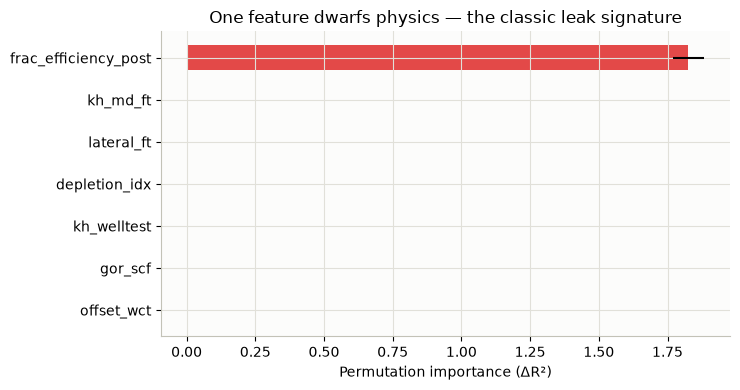

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import r2_score

FEATURES = df.columns[:-1].tolist()
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df.productivity_boed,
                                          test_size=0.3, random_state=42)
gb = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                               random_state=42).fit(X_tr, y_tr)
print(f"Test R2 (with leak in): {r2_score(y_te, gb.predict(X_te)):.3f}  ← suspiciously good")

imp = permutation_importance(gb, X_te, y_te, n_repeats=20, random_state=42)
order = np.argsort(imp.importances_mean)
plt.figure(figsize=(7.5, 4))
colors = [PALETTE[5] if FEATURES[i] == "frac_efficiency_post" else PALETTE[0]
          for i in order]
plt.barh([FEATURES[i] for i in order], imp.importances_mean[order],
         xerr=imp.importances_std[order], color=colors, height=0.6)
plt.xlabel("Permutation importance (ΔR²)")
plt.title("One feature dwarfs physics — the classic leak signature")
plt.tight_layout()
plt.show()

A feature that (a) dominates everything and (b) has no causal mechanism available at
prediction time is a leak until proven otherwise. Remove and refit.

Test R2 (leak removed): 0.851 ← the honest number


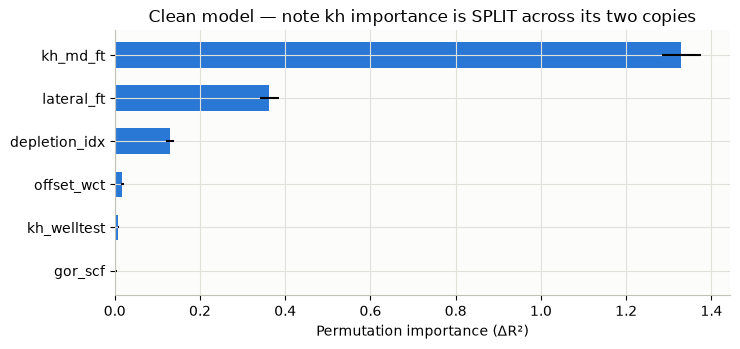

corr(kh_md_ft, kh_welltest) = 0.97 → their importances share one signal


In [4]:
CLEAN = [f for f in FEATURES if f != "frac_efficiency_post"]
gb2 = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05,
                                random_state=42).fit(X_tr[CLEAN], y_tr)
print(f"Test R2 (leak removed): {r2_score(y_te, gb2.predict(X_te[CLEAN])):.3f} "
      f"← the honest number")

imp2 = permutation_importance(gb2, X_te[CLEAN], y_te, n_repeats=20, random_state=42)
order2 = np.argsort(imp2.importances_mean)
plt.figure(figsize=(7.5, 3.6))
plt.barh([CLEAN[i] for i in order2], imp2.importances_mean[order2],
         xerr=imp2.importances_std[order2], color=PALETTE[0], height=0.6)
plt.xlabel("Permutation importance (ΔR²)")
plt.title("Clean model — note kh importance is SPLIT across its two copies")
plt.tight_layout()
plt.show()
print(f"corr(kh_md_ft, kh_welltest) = "
      f"{df.kh_md_ft.corr(df.kh_welltest):.2f} → their importances share one signal")

## 3. PDP + ICE: direction, shape, heterogeneity

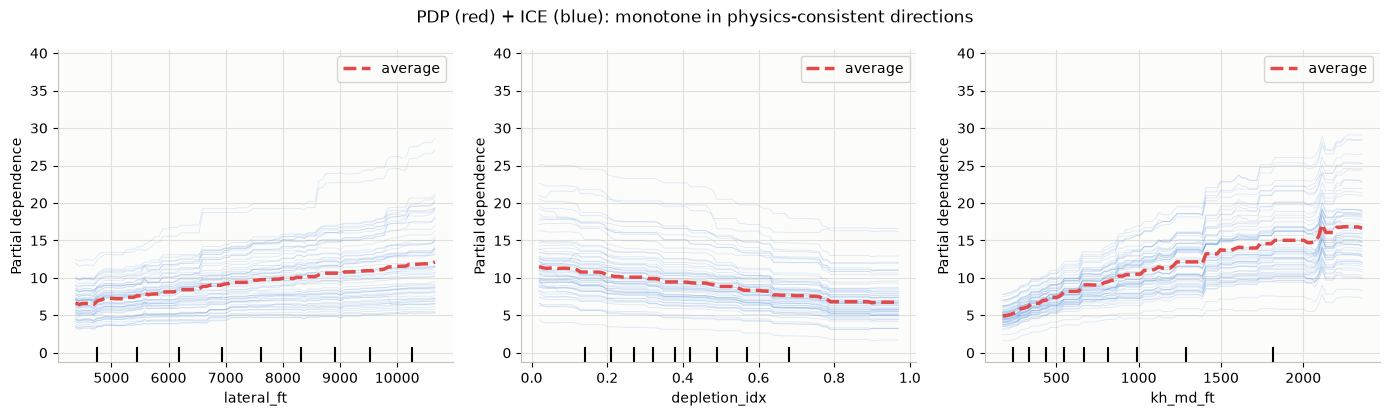

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
PartialDependenceDisplay.from_estimator(
    gb2, X_te[CLEAN], ["lateral_ft", "depletion_idx", "kh_md_ft"],
    kind="both", subsample=60, ax=axes,
    line_kw={"color": PALETTE[5], "lw": 2.5},
    ice_lines_kw={"color": PALETTE[0], "alpha": 0.15, "lw": 0.6})
plt.suptitle("PDP (red) + ICE (blue): monotone in physics-consistent directions")
plt.tight_layout()
plt.show()

The ICE fan on `lateral_ft` is not parallel — some wells gain much more from lateral
length than others. That heterogeneity is the interaction; find its partner.

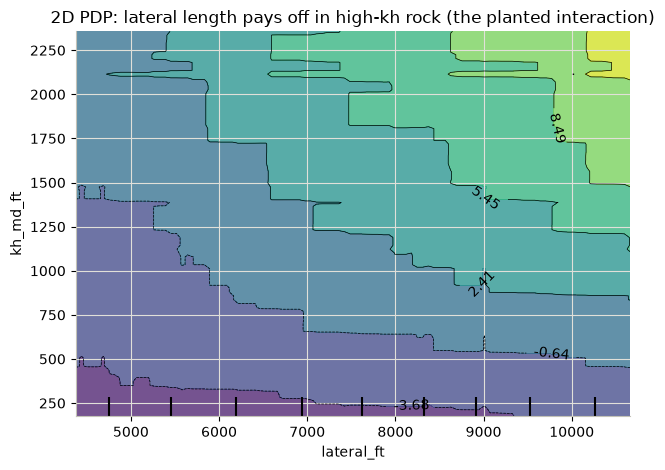

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
PartialDependenceDisplay.from_estimator(
    gb2, X_te[CLEAN], [("lateral_ft", "kh_md_ft")], ax=ax)
plt.title("2D PDP: lateral length pays off in high-kh rock (the planted interaction)")
plt.tight_layout()
plt.show()

## Conclusions

* The workflow caught both traps: the leak announced itself as an impossible
  importance share (and an implausible R²), and the duplicated kh features split one
  physical signal across two bars — the caveat that keeps permutation importance from
  being misread.
* PDPs matched the physics anchors (productivity up with kh and lateral, down with
  depletion), and ICE + 2D PDP recovered the planted kh×lateral interaction — the
  completion-design insight in this dataset.
* This dissection, not the R², is what earns an engineering sign-off.
* **Next step:** SHAP values for per-well (local) explanations and accumulated local
  effects (ALE) where features are too correlated for honest PDPs.